In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.feature_selection import SelectFromModel
import xgboost as xgb

## Data Preparation

In [2]:
df_WTout = pd.read_csv("cmi_internet_WT_outlier_New_features.csv")
df_WTout.drop(columns=['sii','PCIAT-PCIAT_Total'], inplace=True, errors='ignore')

In [3]:
df_WTout

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,...,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,Physical-BMI_New,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec
0,Fall,5.0,0.0,Winter,51.00,Fall,46.000,50.8,26.000,73.90,...,Fall,50.55,71.80,Fall,3,16.877316,6.5,12.3225,2.006,448.0
1,Summer,9.0,0.0,Spring,62.55,Fall,48.000,46.0,22.000,75.00,...,Fall,46.00,64.00,Summer,0,14.035590,11.0,20.6250,2.010,334.0
2,Summer,10.0,1.0,Fall,71.00,Fall,56.500,75.6,25.400,65.00,...,Fall,38.00,54.00,Summer,2,16.648696,10.0,12.4500,2.009,453.0
3,Winter,9.0,0.0,Fall,71.00,Summer,56.000,81.6,26.000,60.00,...,Summer,31.00,45.00,Winter,0,18.292347,7.0,20.6250,2.010,577.0
4,Spring,18.0,1.0,Summer,65.00,Spring,55.003,77.0,26.000,68.00,...,Fall,41.60,61.40,Spring,1,17.894545,9.1,21.5525,1.040,460.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,Spring,7.0,1.0,Spring,65.15,Fall,46.070,49.0,22.250,58.50,...,Summer,38.50,55.00,Spring,0,16.229868,7.0,18.0750,2.000,547.7
8456,Winter,10.0,1.0,Spring,69.50,Winter,56.130,47.8,28.500,66.00,...,Winter,40.50,56.95,Winter,0,10.665793,5.0,13.5750,2.000,451.5
8457,Winter,10.0,1.0,Winter,70.00,Winter,49.560,47.2,25.635,63.50,...,Winter,43.75,60.75,Spring,2,13.509359,9.5,21.0375,2.004,528.0
8458,Fall,15.0,1.0,Spring,55.50,Spring,63.790,99.5,31.100,67.70,...,Winter,39.80,56.15,Fall,1,17.189894,10.5,24.4700,2.000,478.0


In [4]:
df_original = pd.read_csv("dm2_25_26_dataset_tabular/DM2_project/cmi_internet.csv")
df = df_WTout.copy() 

In [5]:
def encoder_labels_categoriques(df):
    """
    Prend un DataFrame en entrée, convertit les variables catégoriques 
    en nombres entiers (0, 1, 2, 3...) dans la même colonne, et retourne le DataFrame.
    """
    # 1. Copier le dataset pour éviter de modifier l'original
    df_encode = df.copy()
    
    # 2. Identifier les colonnes contenant du texte
    colonnes_categoriques = df_encode.select_dtypes(include=['object', 'category']).columns.tolist()
    
    if not colonnes_categoriques:
        print("Aucune colonne catégorique trouvée.")
        return df_encode
    
    # 3. Remplacer le texte par des codes numériques
    for colonne in colonnes_categoriques:
        # Convertit en type catégorie, puis récupère les codes numériques
        df_encode[colonne] = df_encode[colonne].astype('category').cat.codes
        
    return df_encode

In [6]:
df = encoder_labels_categoriques(df)

In [7]:
df["sii"] = df_original["sii"]  # Remettre la colonne 'sii' d'origine après encodage
df.head()

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,...,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,Physical-BMI_New,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec,sii
0,0,5.0,0.0,3,51.00,0,46.000,50.8,26.0,73.9,...,50.55,71.8,0,3,16.877316,6.5,12.3225,2.006,448.0,2.0
1,2,9.0,0.0,1,62.55,0,48.000,46.0,22.0,75.0,...,46.00,64.0,2,0,14.035590,11.0,20.6250,2.010,334.0,0.0
2,2,10.0,1.0,0,71.00,0,56.500,75.6,25.4,65.0,...,38.00,54.0,2,2,16.648696,10.0,12.4500,2.009,453.0,0.0
3,3,9.0,0.0,0,71.00,2,56.000,81.6,26.0,60.0,...,31.00,45.0,3,0,18.292347,7.0,20.6250,2.010,577.0,1.0
4,1,18.0,1.0,2,65.00,1,55.003,77.0,26.0,68.0,...,41.60,61.4,1,1,17.894545,9.1,21.5525,1.040,460.0,0.0


In [8]:
# 1. Identifier les colonnes qui commencent par "PCIAT-PCIAT_"
columns2remove = [c for c in df.columns if c.startswith("PCIAT-PCIAT_")]

# 2. Les supprimer du DataFrame
df = df.drop(columns=columns2remove)

In [9]:
df

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,...,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,Physical-BMI_New,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec,sii
0,0,5.0,0.0,3,51.00,0,46.000,50.8,26.000,73.90,...,50.55,71.80,0,3,16.877316,6.5,12.3225,2.006,448.0,2.0
1,2,9.0,0.0,1,62.55,0,48.000,46.0,22.000,75.00,...,46.00,64.00,2,0,14.035590,11.0,20.6250,2.010,334.0,0.0
2,2,10.0,1.0,0,71.00,0,56.500,75.6,25.400,65.00,...,38.00,54.00,2,2,16.648696,10.0,12.4500,2.009,453.0,0.0
3,3,9.0,0.0,0,71.00,2,56.000,81.6,26.000,60.00,...,31.00,45.00,3,0,18.292347,7.0,20.6250,2.010,577.0,1.0
4,1,18.0,1.0,2,65.00,1,55.003,77.0,26.000,68.00,...,41.60,61.40,1,1,17.894545,9.1,21.5525,1.040,460.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,1,7.0,1.0,1,65.15,0,46.070,49.0,22.250,58.50,...,38.50,55.00,1,0,16.229868,7.0,18.0750,2.000,547.7,0.0
8456,3,10.0,1.0,1,69.50,3,56.130,47.8,28.500,66.00,...,40.50,56.95,3,0,10.665793,5.0,13.5750,2.000,451.5,1.0
8457,3,10.0,1.0,3,70.00,3,49.560,47.2,25.635,63.50,...,43.75,60.75,1,2,13.509359,9.5,21.0375,2.004,528.0,0.0
8458,0,15.0,1.0,1,55.50,1,63.790,99.5,31.100,67.70,...,39.80,56.15,0,1,17.189894,10.5,24.4700,2.000,478.0,2.0


In [10]:
import sys
import os

sys.path.append(os.path.abspath("./lore"))

from util import record2str, neuclidean
from datamanager import prepare_adult_dataset, prepare_dataset

In [11]:
class_name    = 'sii'
class_values  = ['None', 'Mild', 'Moderate', 'Severe']  # sii : 0-3

In [12]:
res = prepare_dataset(df, class_name)
df, feature_names, class_values, numeric_columns, rdf, real_feature_names, features_map = res
df.head()

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,...,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,Physical-BMI_New,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec,sii
0,0,5.0,0.0,3,51.00,0,46.000,50.8,26.0,73.9,...,50.55,71.8,0,3,16.877316,6.5,12.3225,2.006,448.0,2
1,2,9.0,0.0,1,62.55,0,48.000,46.0,22.0,75.0,...,46.00,64.0,2,0,14.035590,11.0,20.6250,2.010,334.0,0
2,2,10.0,1.0,0,71.00,0,56.500,75.6,25.4,65.0,...,38.00,54.0,2,2,16.648696,10.0,12.4500,2.009,453.0,0
3,3,9.0,0.0,0,71.00,2,56.000,81.6,26.0,60.0,...,31.00,45.0,3,0,18.292347,7.0,20.6250,2.010,577.0,1
4,1,18.0,1.0,2,65.00,1,55.003,77.0,26.0,68.0,...,41.60,61.4,1,1,17.894545,9.1,21.5525,1.040,460.0,0


In [13]:
from sklearn.model_selection import train_test_split, cross_val_score 
from sklearn.metrics import roc_curve, auc, roc_auc_score, accuracy_score, f1_score, classification_report

In [14]:
test_size = 0.30
random_state = 0

X_train, X_test, y_train, y_test = train_test_split(
    df[feature_names].values, df[class_name].values,
    test_size=test_size,
    random_state=random_state, 
    stratify=df[class_name].values
)

In [15]:
X_train

array([[  0.   ,   8.   ,   1.   , ...,  18.025,   2.   , 548.5  ],
       [  3.   ,   8.   ,   0.   , ...,  18.025,   2.002, 478.   ],
       [  2.   ,   6.   ,   0.   , ...,  20.625,   2.01 , 448.   ],
       ...,
       [  1.   ,  12.   ,   0.   , ...,  20.625,   2.01 , 448.   ],
       [  3.   ,   8.   ,   0.   , ...,  18.125,   2.   , 535.5  ],
       [  3.   ,  10.   ,   0.   , ...,  20.625,   2.01 , 448.   ]],
      shape=(5922, 63))

# Classification

In [16]:
from sklearn.ensemble import RandomForestClassifier

In [17]:
bb = RandomForestClassifier(n_estimators=20, random_state=42)
bb.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",20
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [18]:
def bb_predict(X):
    return bb.predict(X)

def bb_predict_proba(X):
    return bb.predict_proba(X)

In [19]:
y_pred = bb_predict(X_test)

print(f'Accuracy  : {accuracy_score(y_test, y_pred):.3f}')
print(f'F1 (macro): {f1_score(y_test, y_pred, average="macro"):.3f}')


Accuracy  : 0.685
F1 (macro): 0.307


## Global

In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

In [21]:
y_pred_train = bb_predict(X_train)

In [22]:
explainer = DecisionTreeClassifier(max_depth=4)
explainer.fit(X_train, y_pred_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

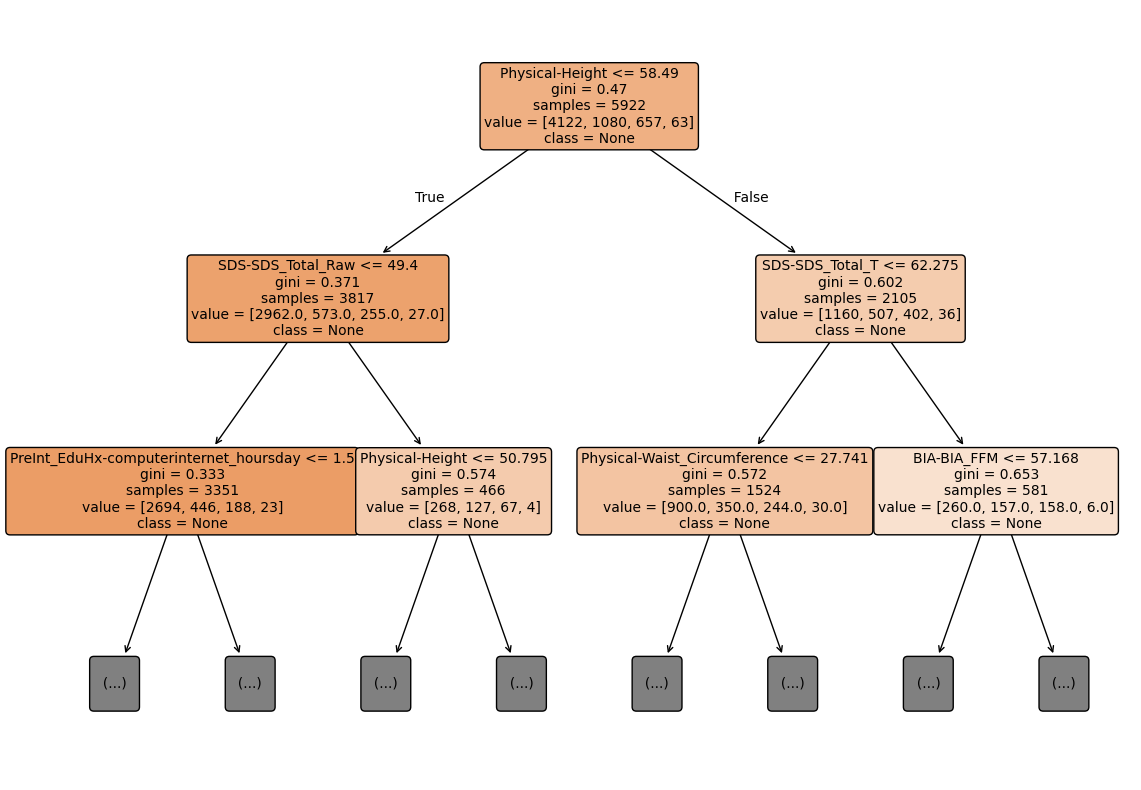

In [23]:
plt.figure(figsize=(14, 10))
plot_tree(
    explainer,
    feature_names=feature_names,
    class_names=['None', 'Mild', 'Moderate', 'Severe'],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=2
)
plt.show()

In [24]:
y_pred_explainer = explainer.predict(X_test)
y_pred_bb = bb.predict(X_test)

accuracy_score(y_pred_bb, y_pred_explainer) # fidelity

0.9235618597320725

In [25]:
accuracy_score(y_test, y_pred_explainer)

0.6855791962174941

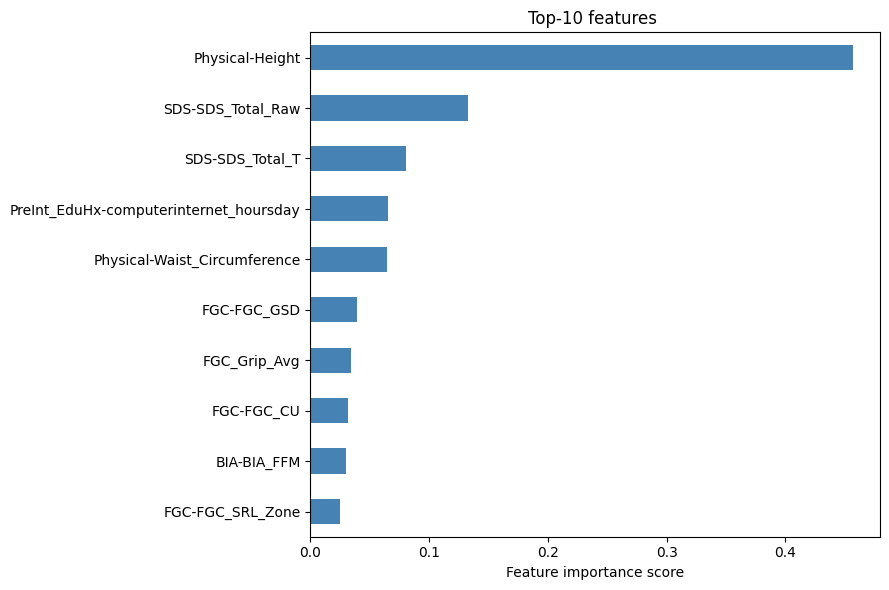

In [26]:
# Top features from the explainer tree

importances = pd.Series(explainer.feature_importances_, index=feature_names)
top20 = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 6))
top20.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.xlabel('Feature importance score')
plt.title('Top-10 features ')
plt.tight_layout()
plt.show()

# Local Explainer
We now explain **individual predictions**.  
Pick an instance from the test set and inspect what the black-box predicts for it.

In [27]:
# Trouver tous les indices dans le set de test où le vrai label est 3
indices_classe_3 = np.where(y_test == 3)[0]

print("Indices disponibles dans X_test ayant le label 3 :", indices_classe_3)

# Choisissons par exemple le premier enfant de classe 3 disponible dans le set de test
i2e = indices_classe_3[0] 
print(f"Index choisi pour l'explication : {i2e}")

# Maintenant, sélectionnez ce point pour votre modèle et vos explications
#x = X_test[i2e]

Indices disponibles dans X_test ayant le label 3 : [  52   67  107  312  505  657  709  800  910  926 1035 1193 1225 1322
 1595 1715 1789 1855 1934 2141 2166 2253 2257 2425 2487 2536]
Index choisi pour l'explication : 52


In [28]:
i2e = 52 # severe
x = X_test[i2e]

# Show the instance as a readable Series
x_df = pd.Series(x, index=feature_names)
print(x_df.to_string())

Basic_Demos-Enroll_Season                    1.000000
Basic_Demos-Age                             14.000000
Basic_Demos-Sex                              1.000000
CGAS-Season                                  1.000000
CGAS-CGAS_Score                             65.000000
Physical-Season                              1.000000
Physical-Height                             60.750000
Physical-Weight                             99.400000
Physical-Waist_Circumference                26.000000
Physical-Diastolic_BP                      105.000000
Physical-HeartRate                          81.000000
Physical-Systolic_BP                       145.000000
Fitness_Endurance-Season                     1.000000
Fitness_Endurance-Max_Stage                  5.000000
Fitness_Endurance-Time_Mins                  7.100000
Fitness_Endurance-Time_Sec                  28.000000
FGC-Season                                   3.000000
FGC-FGC_CU                                   8.100000
FGC-FGC_CU_Zone             

In [29]:
bb_outcome     = bb_predict(x.reshape(1, -1))[0]
bb_outcome_str = class_values[bb_outcome]
true_label_str = class_values[y_test[i2e]]

print(f'True label : {true_label_str} (sii={y_test[i2e]})')
print(f'RF predicts: {bb_outcome_str} (sii={bb_outcome})')
print(f'Probabilities: { {class_values[i]: round(p,3) for i,p in enumerate(bb_predict_proba(x.reshape(1,-1))[0])} }')

True label : 3.0 (sii=3)
RF predicts: 2.0 (sii=2)
Probabilities: {np.float64(0.0): np.float64(0.225), np.float64(1.0): np.float64(0.25), np.float64(2.0): np.float64(0.5), np.float64(3.0): np.float64(0.025)}


## LIME

**LIME** (Local Interpretable Model-agnostic Explanations) fits a locally weighted linear model around the instance `x` to explain *why* the black-box made a particular prediction.

In [ ]:
!pip install lime

In [30]:
try:
    from lime.lime_tabular import LimeTabularExplainer
except ModuleNotFoundError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "lime"])
    from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    X_train,
    feature_names=feature_names,
    class_names=['None', 'Mild', 'Moderate', 'Severe'], 
    discretize_continuous=False
)

In [33]:
lime_exp = lime_explainer.explain_instance(
    x,
    bb_predict_proba,
    num_features=15,
    top_labels=len(class_values)
)

# Visualise explanation for the predicted class
lime_exp.show_in_notebook(show_table=True, show_all=False)

In [31]:
exp = lime_explainer.explain_instance(x, bb_predict_proba)

In [32]:
exp.local_exp

{1: [(np.int64(40), np.float64(-0.007178727786113336)),
  (np.int64(6), np.float64(0.004496260895918951)),
  (np.int64(44), np.float64(-0.004026838005773468)),
  (np.int64(0), np.float64(-0.00345464033792468)),
  (np.int64(9), np.float64(0.0026673021922103356)),
  (np.int64(57), np.float64(0.002215309722074848)),
  (np.int64(16), np.float64(0.001975266888710287)),
  (np.int64(2), np.float64(-0.001957856658366026)),
  (np.int64(11), np.float64(0.0016455276834681613)),
  (np.int64(1), np.float64(0.0015716556574518366))]}

In [34]:
true_label_str = class_values[y_test[i2e]]

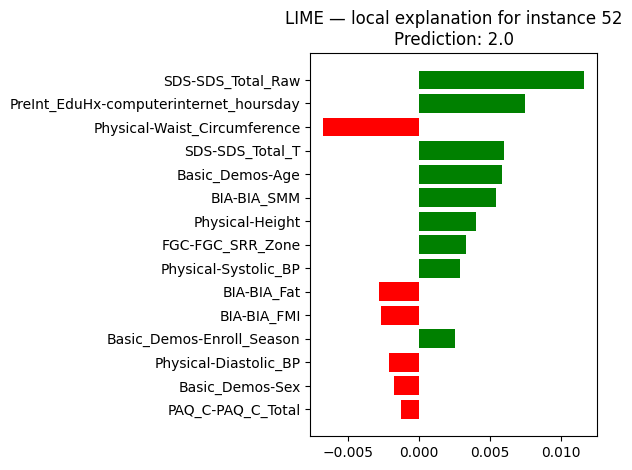

In [35]:
# Bar-chart alternative (works outside Jupyter too)
fig = lime_exp.as_pyplot_figure(label=bb_outcome)
plt.title(f'LIME — local explanation for instance {i2e}\nPrediction: {bb_outcome_str}')
plt.tight_layout()
plt.show()

## SHAP

**SHAP** (SHapley Additive exPlanations) provides game-theory-based feature attributions.  
We use `TreeExplainer` (fast, exact for tree ensembles) to explain the Random Forest.

In [36]:
import shap
shap.initjs()

# TreeExplainer is exact and fast for Random Forest
shap_explainer = shap.TreeExplainer(bb, X_train)

In [37]:
# SHAP values for the single instance  (shape: [n_classes, n_features])
shap_values_single = shap_explainer.shap_values(x)

In [38]:
f = lambda x: bb_predict_proba(x)[:, 1]
med = np.median(X_train, axis=0).reshape((1, X_train.shape[1]))

shap_explainer = shap.KernelExplainer(f, med)

In [39]:
shap_values_single = shap_explainer.shap_values(x, nsamples=1000)

In [40]:
shap_values_single

array([ 0.        ,  0.00941048, -0.03289884,  0.        ,  0.        ,
        0.        ,  0.09334852,  0.00679692,  0.        ,  0.11210624,
        0.        ,  0.06259615,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.01059035,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
       -0.04364437,  0.0134423 ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.01825225,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ])

In [41]:
shap.force_plot(shap_explainer.expected_value, shap_values_single, features=x, feature_names=feature_names)

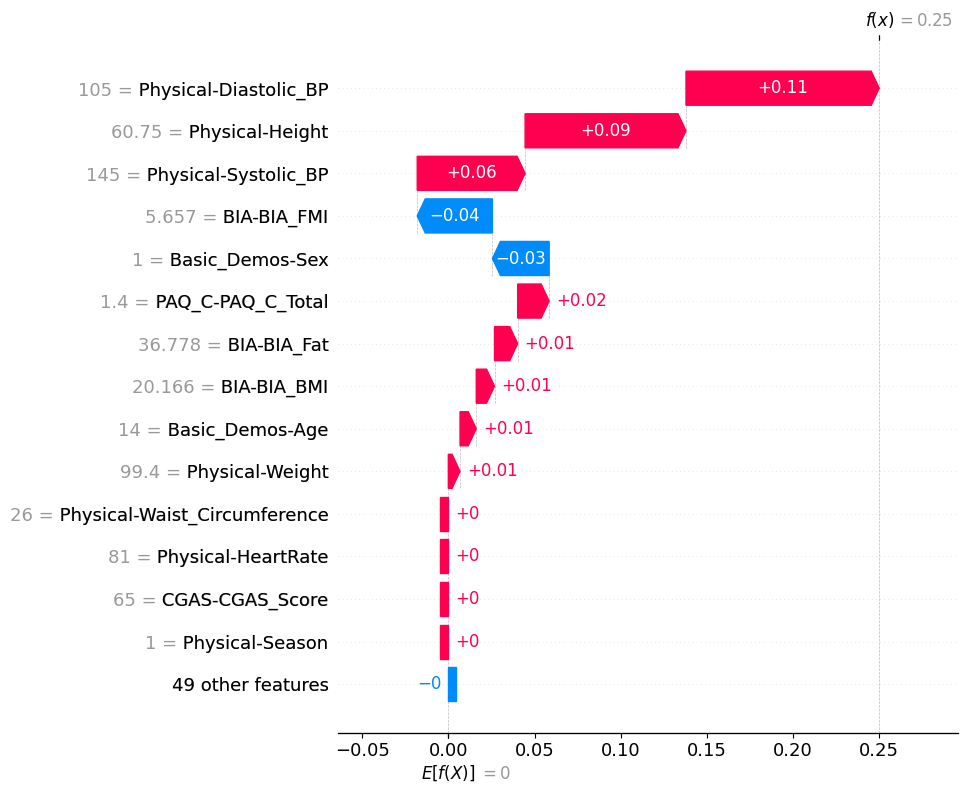

In [42]:
# Waterfall plot (cleaner alternative)
shap_exp_obj = shap.Explanation(
    values=shap_values_single,
    base_values=shap_explainer.expected_value,
    data=x,
    feature_names=feature_names
)
shap.plots.waterfall(shap_exp_obj, max_display=15, show=True)

  0%|          | 0/200 [00:00<?, ?it/s]

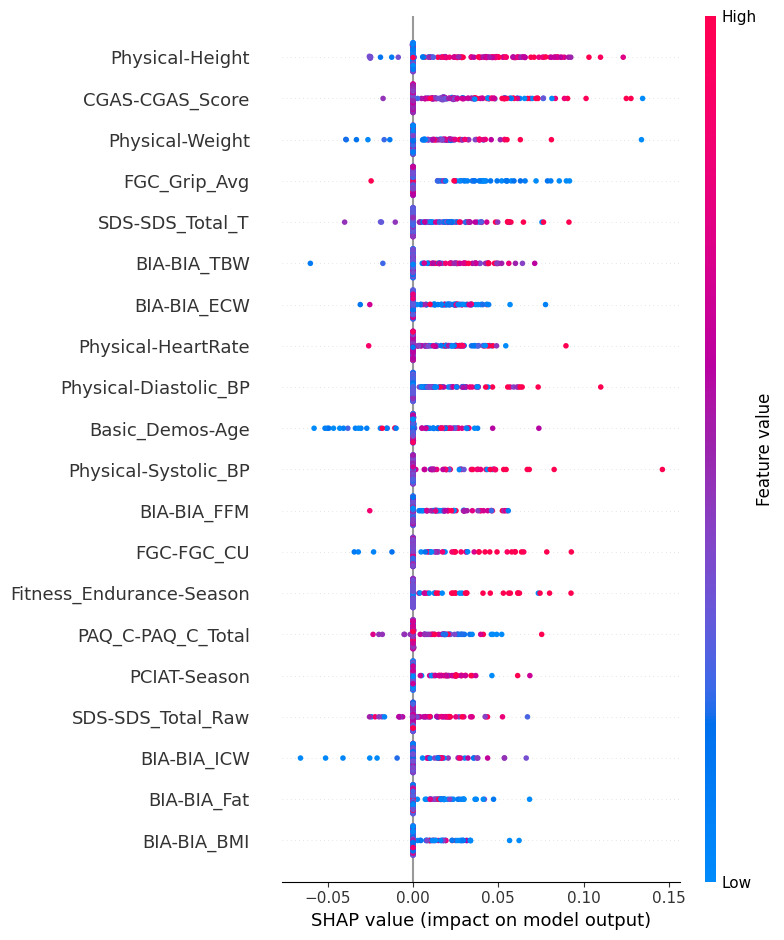

<Figure size 640x480 with 0 Axes>

In [44]:
# Global SHAP — summary plot over the test set
# (computationally heavier: reduce n_samples if slow)
n_samples = min(200, X_test.shape[0])
shap_values_test = shap_explainer.shap_values(
    X_test[:n_samples],
    check_additivity=False
)

shap.summary_plot(
    shap_values_test,
    X_test[:n_samples],
    feature_names=feature_names,
    max_display=20,
    show=True
)
plt.tight_layout()

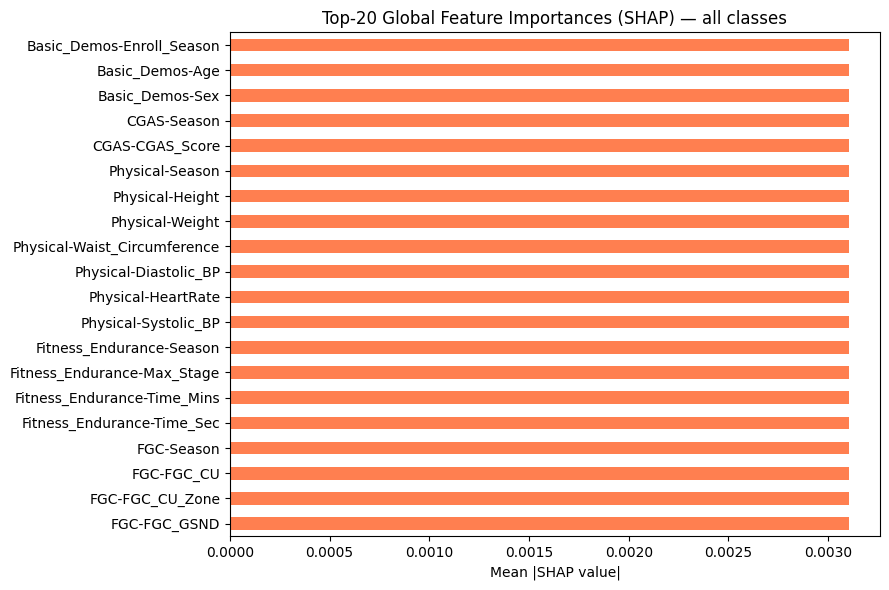

In [45]:
# SHAP bar plot: mean absolute value across all classes
shap_mean_abs = np.mean(
    [np.abs(shap_values_test[c]) for c in range(len(class_values))], axis=(0, 1)
)
shap_importance = pd.Series(shap_mean_abs, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
shap_importance.head(20).plot(kind='barh', color='coral')
plt.gca().invert_yaxis()
plt.xlabel('Mean |SHAP value|')
plt.title('Top-20 Global Feature Importances (SHAP) — all classes')
plt.tight_layout()
plt.show()

## LORE

In [46]:
try:
    try:
        from lorem import LOREM
    except (ImportError, ModuleNotFoundError):
        import sys, subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "lore", "deap", "bitarray"])
        from lorem import LOREM
except ModuleNotFoundError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "bitarray"])
    from lorem import LOREM

In [47]:
_, K, _, _ = train_test_split(
    rdf[real_feature_names].values, 
    rdf[class_name].values, 
    test_size=test_size,
    random_state=random_state, 
    stratify=df[class_name].values
)

In [48]:
lore_explainer = LOREM(K, bb_predict, feature_names, class_name, class_values, numeric_columns, features_map,
                       neigh_type='geneticp', categorical_use_prob=True, continuous_fun_estimation=False, 
                       size=1000, ocr=0.1, random_state=42, ngen=10, bb_predict_proba=bb_predict_proba, 
                       verbose=True)

calculating feature values


In [49]:
exp = lore_explainer.explain_instance(x, samples=300, use_weights=True, metric=neuclidean)

generating neighborhood - geneticp
gen	nevals	avg     	min     	max     
0  	150   	0,496654	0,496654	0,496654
1  	130   	0,744092	0,496654	0,99246 
2  	135   	0,929979	0,496654	0,993199
3  	120   	0,957894	0,776632	0,992572
4  	127   	0,961122	0,727902	0,992871
5  	125   	0,962499	0,737976	0,992871
6  	125   	0,958289	0,699628	0,993081
7  	129   	0,967759	0,804082	0,992871
8  	128   	0,963566	0,677874	0,993171
9  	130   	0,96374 	0,815565	0,993125
10 	123   	0,965219	0,798592	0,993125
gen	nevals	avg	min	max
0  	150   	0,5	0,5	0,5
1  	130   	0,520637	0,5	0,711842
2  	136   	0,543045	0,5	0,831209
3  	125   	0,569062	0,501513	0,831209
4  	130   	0,593658	0,500209	0,831209
5  	132   	0,610539	0,50032 	0,831209
6  	129   	0,628867	0,501985	0,831209
7  	128   	0,627189	0,501185	0,831209
8  	121   	0,637764	0,507894	0,831209
9  	124   	0,648464	0,499992	0,831209
10 	124   	0,655553	0,503274	0,83121 
synthetic neighborhood class counts {np.float64(0.0): np.int64(251), np.float64(1.0): np.int6

In [50]:
print(exp)

r = { Physical-Systolic_BP > 140.00, PreInt_EduHx-computerinternet_hoursday > 1.50, BIA-BIA_FFMI > 14.12, FGC-FGC_PU <= 6.00, CGAS-Season > 0.50, BIA-BIA_TBW <= 50.79, FGC-FGC_TL_Zone > 0.50, BIA-BIA_BMC <= 7.08, FGC-FGC_SRR > 7.90 } --> { sii: 2.0 }
c = { { PreInt_EduHx-computerinternet_hoursday <= 1.50, FGC-FGC_TL > 10.19, FGC-Season <= 1.50 } }


In [51]:
x1 = x.copy()
x1[feature_names.index('Physical-Height')] = 70

print('x1 = %s' % record2str(x1, feature_names, numeric_columns))
print('')

x1 = { Basic_Demos-Enroll_Season = 1.0, Basic_Demos-Age = 14.0, Basic_Demos-Sex = 1.0, CGAS-Season = 1.0, CGAS-CGAS_Score = 65.0, Physical-Season = 1.0, Physical-Height = 70.0, Physical-Weight = 99.4, Physical-Waist_Circumference = 26.0, Physical-Diastolic_BP = 105.0, Physical-HeartRate = 81.0, Physical-Systolic_BP = 145.0, Fitness_Endurance-Season = 1.0, Fitness_Endurance-Max_Stage = 5.0, Fitness_Endurance-Time_Mins = 7.1, Fitness_Endurance-Time_Sec = 28.0, FGC-Season = 3.0, FGC-FGC_CU = 8.1, FGC-FGC_CU_Zone = 0.0, FGC-FGC_GSND = 20.04999999999984, FGC-FGC_GSND_Zone = 2.0, FGC-FGC_GSD = 21.2, FGC-FGC_GSD_Zone = 2.0, FGC-FGC_PU = 3.0, FGC-FGC_PU_Zone = 0.0, FGC-FGC_SRL = 9.0, FGC-FGC_SRL_Zone = 1.0, FGC-FGC_SRR = 8.8, FGC-FGC_SRR_Zone = 1.0, FGC-FGC_TL = 10.0, FGC-FGC_TL_Zone = 1.0, BIA-Season = 2.0, BIA-BIA_Activity_Level_num = 3.0, BIA-BIA_BMC = 4.301125304125055, BIA-BIA_BMI = 20.16622378682726, BIA-BIA_BMR = 1112.9666878556204, BIA-BIA_DEE = 1863.98, BIA-BIA_ECW = 15.928, BIA-BIA_F

In [52]:
bb_outcome = bb_predict(x1.reshape(1, -1))[0]
bb_outcome_str = class_values[bb_outcome]

print('bb(x) = { %s }' % bb_outcome_str)
print('')

bb(x) = { 2.0 }



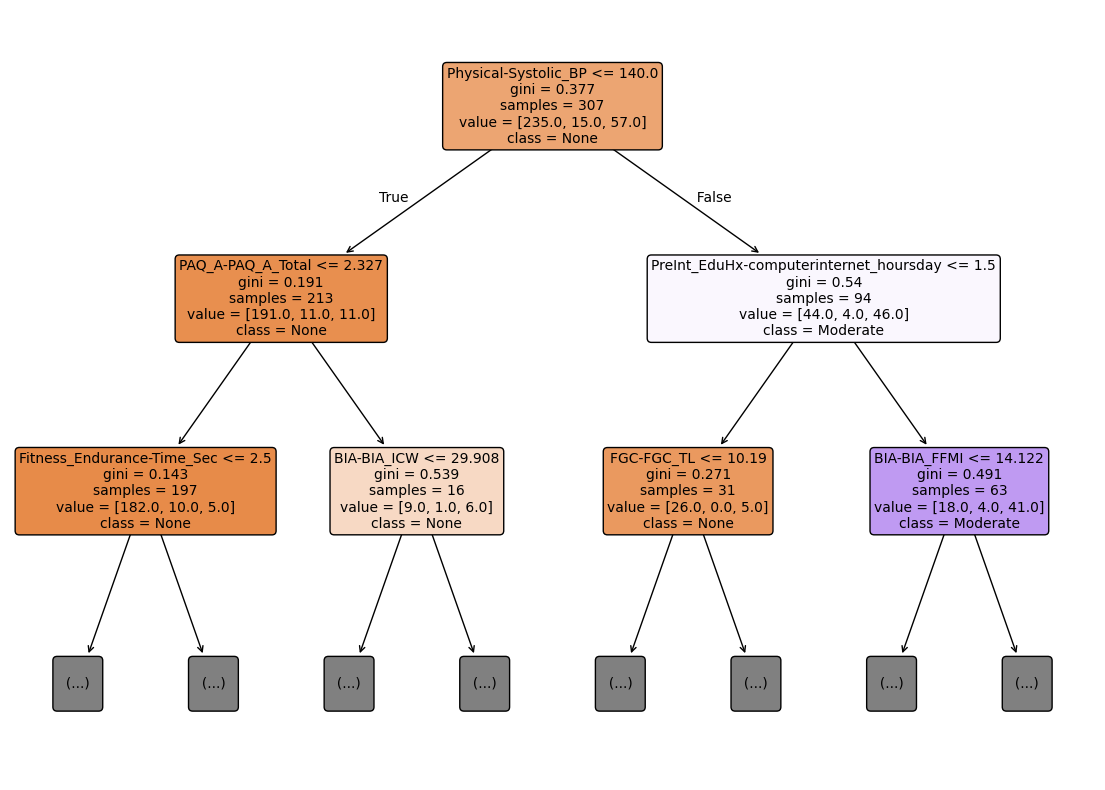

In [56]:
plt.figure(figsize=(14, 10))
plot_tree(exp.dt, 
          feature_names=feature_names, 
          class_names=['None', 'Mild', 'Moderate', 'Severe'], 
          filled=True, 
          rounded=True,
          fontsize=10,
          max_depth=2)  
plt.show()

## Counterfactual Explanations
A **counterfactual** answers: *What is the smallest change to x that would flip the prediction?*  
We use `fat-forensics` (same library as the original notebook).

In [ ]:
!pip install fat-forensics

In [59]:
import sys, subprocess

try:
    import fatf.transparency.predictions.counterfactuals as fatf_cf
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "fat-forensics"])
    import fatf.transparency.predictions.counterfactuals as fatf_cf

26-giu-04 16:54:44 fatf.utils.array.tools INFO     Using numpy's numpy.lib.recfunctions.structured_to_unstructured as fatf.utils.array.tools.structured_to_unstructured and fatf.utils.array.tools.structured_to_unstructured_row.


In [62]:
# Create a Counterfactual Explainer
cf_explainer = fatf_cf.CounterfactualExplainer(
    model=bb,
    dataset=X_test.astype(float), # cast booleans to float, library dataset has to be of a base type (strings and/or numbers).
    categorical_indices=[],
    default_numerical_step_size=1,
    max_counterfactual_length=1
)

In [63]:
dp_1_cf_tuple = cf_explainer.explain_instance(x1.astype(float))
dp_1_cfs, dp_1_cfs_distances, dp_1_cfs_predictions = dp_1_cf_tuple

In [64]:
dp_1_cfs

array([[  1.   ,  14.   ,   1.   , ...,  20.625,   2.107, 454.   ],
       [  1.   ,  14.   ,   1.   , ...,  20.625,   2.107, 454.   ],
       [  1.   ,  14.   ,   1.   , ...,  20.625,   2.107, 454.   ],
       ...,
       [  1.   ,  14.   ,   1.   , ...,  20.625,   2.107, 454.   ],
       [  1.   ,  14.   ,   1.   , ...,  20.625,   2.107, 454.   ],
       [  1.   ,  14.   ,   1.   , ...,  20.625,   2.107, 454.   ]],
      shape=(16, 63))

In [65]:
dp_1_cfs_text = fatf_cf.textualise_counterfactuals(
    x1.astype(float),
    dp_1_cfs,
    instance_class=bb_outcome,
    counterfactuals_distances=dp_1_cfs_distances,
    counterfactuals_predictions=dp_1_cfs_predictions)
print(dp_1_cfs_text)

Instance (of class *2*):
[1.00000000e+00 1.40000000e+01 1.00000000e+00 1.00000000e+00
 6.50000000e+01 1.00000000e+00 7.00000000e+01 9.94000000e+01
 2.60000000e+01 1.05000000e+02 8.10000000e+01 1.45000000e+02
 1.00000000e+00 5.00000000e+00 7.10000000e+00 2.80000000e+01
 3.00000000e+00 8.10000000e+00 0.00000000e+00 2.00500000e+01
 2.00000000e+00 2.12000000e+01 2.00000000e+00 3.00000000e+00
 0.00000000e+00 9.00000000e+00 1.00000000e+00 8.80000000e+00
 1.00000000e+00 1.00000000e+01 1.00000000e+00 2.00000000e+00
 3.00000000e+00 4.30112530e+00 2.01662238e+01 1.11296669e+03
 1.86398000e+03 1.59280000e+01 6.10662000e+01 1.41520724e+01
 5.65747415e+00 3.67779196e+01 2.00000000e+00 2.88558000e+01
 1.64388000e+01 5.69964000e+01 2.74151000e+01 4.44063744e+01
 3.00000000e+00 2.10700000e+00 1.00000000e+00 1.40000000e+00
 1.00000000e+00 1.00000000e+00 4.40000000e+01 6.20000000e+01
 1.00000000e+00 3.00000000e+00 1.89342952e+01 8.90000000e+00
 2.06250000e+01 2.10700000e+00 4.54000000e+02]

Feature name

## DALEX

**DALEX** provides a unified framework for model explanation.  
We use it for:
- **Break-Down** plots (additive local explanation)
- **Shapley values** (consistent with game theory)
- **Partial Dependence Profiles** (global)

References:
- https://dalex.drwhy.ai/python-dalex-titanic.html
- https://github.com/ModelOriented/DALEX

In [ ]:
!pip install dalex

In [68]:
try:
    import dalex as dx
except ModuleNotFoundError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "dalex"])
    import dalex as dx

# DALEX explainer (wraps the model and data)
# For multi-class RF, we wrap predict_proba for the predicted class
# DALEX natively supports multi-class with type='multiclass'
dalex_explainer = dx.Explainer(
    bb,
    pd.DataFrame(X_train, columns=feature_names),
    y_train,
    label='Random Forest (CMI sii)',
    model_type='multiclass'
)

Preparation of a new explainer is initiated

  -> data              : 5922 rows 63 cols
  -> target variable   : 5922 values
  -> model_class       : sklearn.ensemble._forest.RandomForestClassifier (default)
  -> label             : Random Forest (CMI sii)
  -> predict function  : <function yhat_proba_default at 0x000001A10018B560> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.0, mean = 0.189, max = 1.0
  -> model type        : multiclass will be used
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.54, mean = 0.254, max = 3.0
  -> model_info        : package sklearn

A new explainer has been created!


In [69]:
# Break-Down plot for the chosen instance 
x_dalex = pd.DataFrame([x], columns=feature_names)

bd = dalex_explainer.predict_parts(
    x_dalex,
    type='break_down',
    label=f'Instance {i2e} — {bb_outcome_str}'
)
bd.plot()

In [70]:
# SHAP (Shapley) via DALEX 
shap_dalex = dalex_explainer.predict_parts(
    x_dalex,
    type='shap',
    B=10,                    # number of random orderings
    label=f'Instance {i2e}'
)
shap_dalex.plot(max_vars=15)

In [71]:
# Global: Variable Importance (permutation-based) 
vi = dalex_explainer.model_parts(N=300, B=5, random_state=random_state)
vi.plot(max_vars=20)

In [72]:
# Partial Dependence Profile for top features 
# Choose the top 3 features by permutation importance
top3_features = (
    vi.result
    .query('variable != "_baseline_" and variable != "_full_model_"')
    .nlargest(3, 'dropout_loss')['variable']
    .tolist()
)
print('Top-3 features for PDP:', top3_features)

pdp = dalex_explainer.model_profile(
    variables=top3_features,
    N=300,
    type='partial',
    label='PDP'
)
pdp.plot()

Top-3 features for PDP: ['Basic_Demos-Age', 'PreInt_EduHx-computerinternet_hoursday', 'SDS-SDS_Total_Raw']


Calculating ceteris paribus: 100%|██████████| 3/3 [00:00<00:00, 10.53it/s]
